# Taller 02: Poda Alfa-Beta
**Inteligencia Artificial - ELP 8012 - Universidad del Norte**
Profesor: Eduardo Zurek, Ph.D.

Este cuaderno implementa un algoritmo **genérico** de poda Alfa-Beta que opera sobre
árboles de juego representados con listas anidadas de Python, por ejemplo:

```python
[ [3,-5,2] , [-5,-7,4] , [-9,6,-8] ]
```

El árbol puede tener **hasta 5 niveles** y **hasta 50 nodos hoja**. El cuaderno permite:

1. Definir el árbol manualmente mediante una lista anidada (celda de configuración).
2. Generar el árbol **aleatoriamente**, indicando el número de niveles y el número de nodos hoja.
3. Ejecutar la poda Alfa-Beta de forma genérica (cualquier factor de ramificación, cualquier profundidad).
4. Visualizar la **secuencia óptima de jugadas** y las **ramas podadas**.

In [1]:
import math
import random
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline

## Configuración del árbol

Modifique la siguiente lista para definir el árbol de juego que desea analizar.
Cada sub-lista representa un nodo interno; los números son los valores de las hojas.
La raíz siempre es un nodo **MAX**, y los niveles se alternan MAX/MIN a medida que se
desciende en el árbol.

In [2]:
# Lista de entrada que describe el árbol (editar aquí)
arbol_entrada = [ [3, -5, 2], [-5, -7, 4], [-9, 6, -8] ]

arbol_entrada

[[3, -5, 2], [-5, -7, 4], [-9, 6, -8]]

## 1. Representación del árbol

Convertimos la lista anidada de Python en una estructura de nodos (`Nodo`) que
permite guardar, para cada nodo, la información generada durante la poda: el valor
calculado, si fue podado o no, cuál es su mejor hijo (para reconstruir la secuencia
óptima), su profundidad y su posición para graficarlo.

In [3]:
class Nodo:
    _contador = 0

    def __init__(self, valor=None, hijos=None, nombre=None):
        self.valor = valor
        self.hijos = hijos if hijos is not None else []
        self.es_hoja = len(self.hijos) == 0
        self.nombre = nombre if nombre is not None else str(Nodo._contador)
        Nodo._contador += 1

        # Atributos que se llenan durante la poda alfa-beta
        self.valor_calculado = None
        self.podado = False          # True si el nodo nunca fue evaluado (rama podada)
        self.visitado = False
        self.mejor_hijo = None       # hijo que produce el valor óptimo
        self.profundidad = 0
        self.orden_visita = None     # orden en que fue explorado

        # Atributos de layout (se llenan al graficar)
        self.x = None
        self.y = None


MAX_NIVELES = 5
MAX_HOJAS = 50


def _validar_arbol(lista):
    """Recorre la lista anidada y verifica que respete hasta MAX_NIVELES niveles
    y hasta MAX_HOJAS nodos hoja. Lanza ValueError si no se cumple."""

    def _explorar(x, profundidad):
        if isinstance(x, list):
            if len(x) == 0:
                raise ValueError(f"Nodo interno vacío (sin hijos) en profundidad {profundidad}")
            if profundidad + 1 > MAX_NIVELES:
                raise ValueError(
                    f"El árbol supera el máximo de {MAX_NIVELES} niveles "
                    f"(se encontró un nodo en el nivel {profundidad + 1})."
                )
            total = 0
            for item in x:
                total += _explorar(item, profundidad + 1)
            return total
        else:
            return 1  # es una hoja

    total_hojas = _explorar(lista, 0)
    if total_hojas > MAX_HOJAS:
        raise ValueError(
            f"El árbol tiene {total_hojas} hojas, y el máximo permitido es {MAX_HOJAS}."
        )
    return total_hojas


def construir_arbol(lista, profundidad=0, nombre="raiz"):
    """Convierte una lista de Python (posiblemente anidada) en un árbol de Nodo.

    - Si `lista` es una lista -> se crea un nodo interno con un hijo por cada elemento.
    - Si `lista` es un número -> se crea un nodo hoja con ese valor.

    Antes de construir el árbol, valida que respete hasta MAX_NIVELES niveles
    y hasta MAX_HOJAS nodos hoja (según lo exige el enunciado del taller).
    """
    if profundidad == 0:
        _validar_arbol(lista)

    if isinstance(lista, list):
        nodo = Nodo(nombre=nombre)
        nodo.profundidad = profundidad
        for i, item in enumerate(lista):
            hijo = construir_arbol(item, profundidad + 1, f"{nombre}.{i}")
            nodo.hijos.append(hijo)
        nodo.es_hoja = False
        return nodo
    else:
        nodo = Nodo(valor=lista, nombre=nombre)
        nodo.profundidad = profundidad
        nodo.es_hoja = True
        nodo.valor_calculado = lista
        return nodo

## 2. Generación aleatoria del árbol

La siguiente función genera una lista anidada de Python que representa un árbol de
juego válido, dado el número de **niveles** (profundidad, máx. 5) y el número total
de **nodos hoja** (máx. 50). En cada nivel se elige aleatoriamente un factor de
ramificación (entre 2 y `max_ramificacion`) y se reparten las hojas restantes entre
las ramas, garantizando que la suma total de hojas sea exactamente la solicitada.

In [4]:
def _particionar(n, k):
    """Reparte n en k enteros positivos (>=1) elegidos al azar, cuya suma es n."""
    if k == 1:
        return [n]
    if n > k - 1:
        cortes = sorted(random.sample(range(1, n), k - 1))
        limites = [0] + cortes + [n]
        return [limites[i + 1] - limites[i] for i in range(k)]
    # No hay suficientes hojas para separar en k grupos distintos:
    # se da 1 hoja a cada grupo y el resto se acumula en el último.
    base = [1] * k
    base[-1] += max(n - k, 0)
    return base


def generar_arbol_aleatorio(niveles, num_hojas, rango_valores=(-10, 10), max_ramificacion=3, semilla=None):
    """
    Genera una lista anidada de Python que representa un árbol de juego con
    exactamente `niveles` niveles de profundidad y `num_hojas` nodos hoja en total.

    Parámetros
    ----------
    niveles : int
        Número de aristas entre la raíz y cada hoja (1 a 5).
    num_hojas : int
        Número total de nodos hoja del árbol (1 a 50).
    rango_valores : tuple
        Rango (mín, máx) para los valores aleatorios de las hojas.
    max_ramificacion : int
        Máximo número de hijos que puede tener un nodo interno.
    semilla : int, opcional
        Semilla para el generador aleatorio (reproducibilidad).
    """
    if semilla is not None:
        random.seed(semilla)
    if not (1 <= niveles <= 5):
        raise ValueError("niveles debe estar entre 1 y 5")
    if not (1 <= num_hojas <= 50):
        raise ValueError("num_hojas debe estar entre 1 y 50")

    def _generar(niveles_restantes, hojas_restantes):
        if niveles_restantes == 1:
            # Último nivel: se crean EXACTAMENTE `hojas_restantes` hojas, una por cada
            # hoja pendiente (así se garantiza el número total de hojas solicitado).
            return [random.randint(*rango_valores) for _ in range(hojas_restantes)]
        ramas = random.randint(2, min(max_ramificacion, hojas_restantes)) if hojas_restantes >= 2 else 1
        grupos = _particionar(hojas_restantes, ramas)
        return [_generar(niveles_restantes - 1, g) for g in grupos]

    return _generar(niveles, num_hojas)


# Ejemplo de uso (sin semilla fija: cada ejecución da un árbol distinto):
print(generar_arbol_aleatorio(niveles=3, num_hojas=10))
print(generar_arbol_aleatorio(niveles=3, num_hojas=10))

[[[8]], [[-5, -4, -1, -9], [0, -5, 5, -7]], [[-9]]]
[[[-2], [-4]], [[8, -3], [-9]], [[-1], [10, 10, 2, 2]]]


### Verificación: el límite de 5 niveles y 50 hojas se respeta siempre

`construir_arbol` valida automáticamente cualquier lista de entrada (manual o generada). Probamos: (1) el caso límite exacto —5 niveles y 50 hojas— que debe funcionar sin problema, y (2) casos que exceden el límite, que deben rechazarse con un error claro.

In [5]:
# Caso límite exacto: 5 niveles y 50 hojas -> debe construirse sin error
arbol_limite = generar_arbol_aleatorio(niveles=5, num_hojas=50)
Nodo._contador = 0
raiz_limite = construir_arbol(arbol_limite)
print("OK: árbol de 5 niveles y 50 hojas construido correctamente.")

# Caso inválido: una lista manual con 6 niveles de profundidad -> debe lanzar ValueError
arbol_muy_profundo = [[[[[[1, 2]]]]]]  # 6 niveles
try:
    construir_arbol(arbol_muy_profundo)
    print("ERROR: debería haber lanzado una excepción")
except ValueError as e:
    print("Rechazado correctamente ->", e)

# Caso inválido: una lista manual con más de 50 hojas -> debe lanzar ValueError
arbol_muchas_hojas = [list(range(60))]
try:
    construir_arbol(arbol_muchas_hojas)
    print("ERROR: debería haber lanzado una excepción")
except ValueError as e:
    print("Rechazado correctamente ->", e)

OK: árbol de 5 niveles y 50 hojas construido correctamente.
Rechazado correctamente -> El árbol supera el máximo de 5 niveles (se encontró un nodo en el nivel 6).
Rechazado correctamente -> El árbol tiene 60 hojas, y el máximo permitido es 50.


### Verificación: el número de hojas generado siempre coincide con lo solicitado

Se prueban varias combinaciones de `niveles` y `num_hojas` (incluido el caso máximo 5 niveles / 50 hojas) y se cuenta cuántas hojas y a qué profundidad quedaron realmente en el árbol generado.

In [6]:
def _contar_hojas(x):
    if isinstance(x, list):
        return sum(_contar_hojas(h) for h in x)
    return 1

def _profundidades_de_hojas(x, d=0):
    if isinstance(x, list):
        profs = set()
        for h in x:
            profs |= _profundidades_de_hojas(h, d + 1)
        return profs
    return {d}

casos = [(1, 1), (1, 50), (2, 5), (3, 10), (4, 20), (5, 33), (5, 50)]
print(f"{'niveles':>8} {'hojas pedidas':>15} {'hojas obtenidas':>18} {'profundidad(es) real(es)':>26}")
for niveles, num_hojas in casos:
    arbol_prueba = generar_arbol_aleatorio(niveles=niveles, num_hojas=num_hojas)
    obtenidas = _contar_hojas(arbol_prueba)
    profs = _profundidades_de_hojas(arbol_prueba)
    ok = "OK" if (obtenidas == num_hojas and profs == {niveles}) else "FALLO"
    print(f"{niveles:>8} {num_hojas:>15} {obtenidas:>18} {str(sorted(profs)):>26}   {ok}")

 niveles   hojas pedidas    hojas obtenidas   profundidad(es) real(es)
       1               1                  1                        [1]   OK
       1              50                 50                        [1]   OK
       2               5                  5                        [2]   OK
       3              10                 10                        [3]   OK
       4              20                 20                        [4]   OK
       5              33                 33                        [5]   OK
       5              50                 50                        [5]   OK


## 3. Algoritmo de poda Alfa-Beta (genérico)

La función `poda_alfabeta` recorre el árbol en profundidad, alternando entre niveles
**MAX** (la raíz y niveles pares) y **MIN** (niveles impares), manteniendo los valores
`alfa` y `beta`. Cuando `alfa >= beta`, el resto de los hijos del nodo actual se
marcan como **podados** (nunca se evalúan), lo cual queda registrado en cada `Nodo`
para poder graficarlo después.

El algoritmo funciona para **cualquier factor de ramificación** y **cualquier
profundidad**, ya que recorre `nodo.hijos` de forma genérica.

In [7]:
_contador_visita = [0]


def _marcar_podado(nodo):
    """Marca recursivamente un nodo y todos sus descendientes como podados (no evaluados)."""
    nodo.podado = True
    for h in nodo.hijos:
        _marcar_podado(h)


def poda_alfabeta(nodo, profundidad=0, alfa=-math.inf, beta=math.inf, maximizando=True):
    """Ejecuta la poda Alfa-Beta de forma genérica sobre un árbol de `Nodo`.

    Devuelve el valor minimax del nodo raíz y anota en cada `Nodo` visitado:
    valor_calculado, mejor_hijo (para la secuencia óptima) y podado (para las ramas podadas).
    """
    nodo.profundidad = profundidad
    nodo.visitado = True
    _contador_visita[0] += 1
    nodo.orden_visita = _contador_visita[0]

    if nodo.es_hoja:
        nodo.valor_calculado = nodo.valor
        return nodo.valor

    if maximizando:
        valor = -math.inf
        for i, hijo in enumerate(nodo.hijos):
            valor_hijo = poda_alfabeta(hijo, profundidad + 1, alfa, beta, False)
            if valor_hijo > valor:
                valor = valor_hijo
                nodo.mejor_hijo = hijo
            alfa = max(alfa, valor)
            if alfa >= beta:                       # poda beta
                for restante in nodo.hijos[i + 1:]:
                    _marcar_podado(restante)
                break
    else:
        valor = math.inf
        for i, hijo in enumerate(nodo.hijos):
            valor_hijo = poda_alfabeta(hijo, profundidad + 1, alfa, beta, True)
            if valor_hijo < valor:
                valor = valor_hijo
                nodo.mejor_hijo = hijo
            beta = min(beta, valor)
            if alfa >= beta:                       # poda alfa
                for restante in nodo.hijos[i + 1:]:
                    _marcar_podado(restante)
                break

    nodo.valor_calculado = valor
    return valor


def obtener_secuencia_optima(raiz):
    """Devuelve la lista de nodos desde la raíz hasta la hoja óptima (jugadas óptimas)."""
    secuencia = [raiz]
    actual = raiz
    while not actual.es_hoja:
        actual = actual.mejor_hijo
        secuencia.append(actual)
    return secuencia

## 4. Visualización

La función `dibujar_arbol` calcula la posición de cada nodo y grafica el árbol:

- **Triángulos azules (▲)**: nodos MAX. **Triángulos rojos (▼)**: nodos MIN.
- **Triángulos grises**: nodos **podados** (nunca evaluados por el algoritmo).
- **Línea verde gruesa**: **secuencia óptima de jugadas** (desde la raíz hasta la hoja elegida).
- **Líneas discontinuas grises con una X roja**: **ramas podadas**.
- Encima de cada nodo interno no podado se muestra su valor minimax calculado; debajo
  de cada hoja se muestra su valor.

In [8]:
def _asignar_posiciones(raiz):
    """Asigna coordenadas (x, y) a cada nodo mediante un recorrido post-orden."""
    contador_x = [0]

    def _recorrer(nodo, profundidad):
        nodo.y = -profundidad
        if nodo.es_hoja:
            nodo.x = contador_x[0]
            contador_x[0] += 1
        else:
            for h in nodo.hijos:
                _recorrer(h, profundidad + 1)
            xs = [h.x for h in nodo.hijos]
            nodo.x = sum(xs) / len(xs)

    _recorrer(raiz, 0)


def dibujar_arbol(raiz, titulo="Poda Alfa-Beta", figsize=None, guardar_en=None):
    """Grafica el árbol, resaltando la secuencia óptima y las ramas podadas."""
    _asignar_posiciones(raiz)
    secuencia_optima = obtener_secuencia_optima(raiz)
    nodos_optimos = set(id(n) for n in secuencia_optima)

    todos_los_nodos = []

    def _recolectar(nodo):
        todos_los_nodos.append(nodo)
        for h in nodo.hijos:
            _recolectar(h)

    _recolectar(raiz)

    max_x = max(n.x for n in todos_los_nodos) + 1
    max_prof = max(n.profundidad for n in todos_los_nodos) + 1
    if figsize is None:
        figsize = (max(8, max_x * 1.1), max(5, max_prof * 2.2))

    fig, ax = plt.subplots(figsize=figsize)

    COLOR_MAX = "#1f77b4"
    COLOR_MIN = "#d62728"
    COLOR_PODADO = "#bdbdbd"
    COLOR_OPTIMO = "#2ca02c"
    COLOR_ARISTA = "#555555"

    def _dibujar_aristas(nodo):
        for hijo in nodo.hijos:
            es_optima = (id(nodo) in nodos_optimos and id(hijo) in nodos_optimos
                         and nodo.mejor_hijo is hijo)
            if hijo.podado:
                ax.plot([nodo.x, hijo.x], [nodo.y, hijo.y], color=COLOR_PODADO,
                        linestyle="--", linewidth=1.5, zorder=1)
            elif es_optima:
                ax.plot([nodo.x, hijo.x], [nodo.y, hijo.y], color=COLOR_OPTIMO,
                        linewidth=3.0, zorder=3)
            else:
                ax.plot([nodo.x, hijo.x], [nodo.y, hijo.y], color=COLOR_ARISTA,
                        linewidth=1.2, zorder=2)
            _dibujar_aristas(hijo)

    _dibujar_aristas(raiz)

    def _marcar_x_podas(nodo):
        for hijo in nodo.hijos:
            if hijo.podado:
                mx, my = (nodo.x + hijo.x) / 2, (nodo.y + hijo.y) / 2
                ax.plot(mx, my, marker="x", color="#e41a1c", markersize=10,
                        markeredgewidth=2.5, zorder=4)
            else:
                _marcar_x_podas(hijo)

    _marcar_x_podas(raiz)

    for nodo in todos_los_nodos:
        es_max = (nodo.profundidad % 2 == 0)
        marcador = "^" if es_max else "v"
        color = COLOR_PODADO if nodo.podado else (COLOR_MAX if es_max else COLOR_MIN)
        tam = 380 if not nodo.es_hoja else 260
        borde = COLOR_OPTIMO if (not nodo.podado and id(nodo) in nodos_optimos) else "black"
        grosor_borde = 2.5 if (not nodo.podado and id(nodo) in nodos_optimos) else 1.0

        ax.scatter(nodo.x, nodo.y, marker=marcador, s=tam, color=color,
                   edgecolors=borde, linewidths=grosor_borde, zorder=5)

        if nodo.es_hoja:
            ax.annotate(str(nodo.valor), (nodo.x, nodo.y), textcoords="offset points",
                        xytext=(0, -18), ha="center", fontsize=10, fontweight="bold")
        elif not nodo.podado:
            ax.annotate(str(nodo.valor_calculado), (nodo.x, nodo.y), textcoords="offset points",
                        xytext=(0, 10), ha="center", fontsize=9,
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

    elementos_leyenda = [
        Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_MAX,
               markeredgecolor="black", markersize=13, label="Nodo MAX"),
        Line2D([0], [0], marker="v", color="w", markerfacecolor=COLOR_MIN,
               markeredgecolor="black", markersize=13, label="Nodo MIN"),
        Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_PODADO,
               markeredgecolor="black", markersize=13, label="Nodo podado (no evaluado)"),
        Line2D([0], [0], color=COLOR_OPTIMO, linewidth=3, label="Secuencia óptima"),
        Line2D([0], [0], color=COLOR_PODADO, linestyle="--", linewidth=1.5, label="Rama podada"),
    ]
    ax.legend(handles=elementos_leyenda, loc="upper center", bbox_to_anchor=(0.5, -0.02),
              ncol=3, fontsize=9, frameon=False)

    valores_secuencia = " -> ".join(
        f"{n.nombre}({n.valor if n.es_hoja else n.valor_calculado})" for n in secuencia_optima
    )
    ax.axis("off")
    ax.set_ylim(min(n.y for n in todos_los_nodos) - 0.6, 1.05)
    fig.suptitle(
        f"{titulo}\nValor óptimo (minimax) en la raíz = {raiz.valor_calculado}   |   "
        f"Secuencia óptima: {valores_secuencia}",
        fontsize=12, fontweight="bold", y=1.06
    )
    plt.tight_layout()
    if guardar_en:
        plt.savefig(guardar_en, dpi=140, bbox_inches="tight")
    return fig, ax, secuencia_optima

## 5. Ejecución con el árbol configurado

Construimos el árbol a partir de `arbol_entrada` (definida en la celda de
configuración), ejecutamos la poda Alfa-Beta y mostramos la figura con la secuencia
óptima de jugadas y las ramas podadas.

Valor óptimo (minimax) en la raíz: -5
Secuencia óptima de jugadas: [-5, -5, -5]


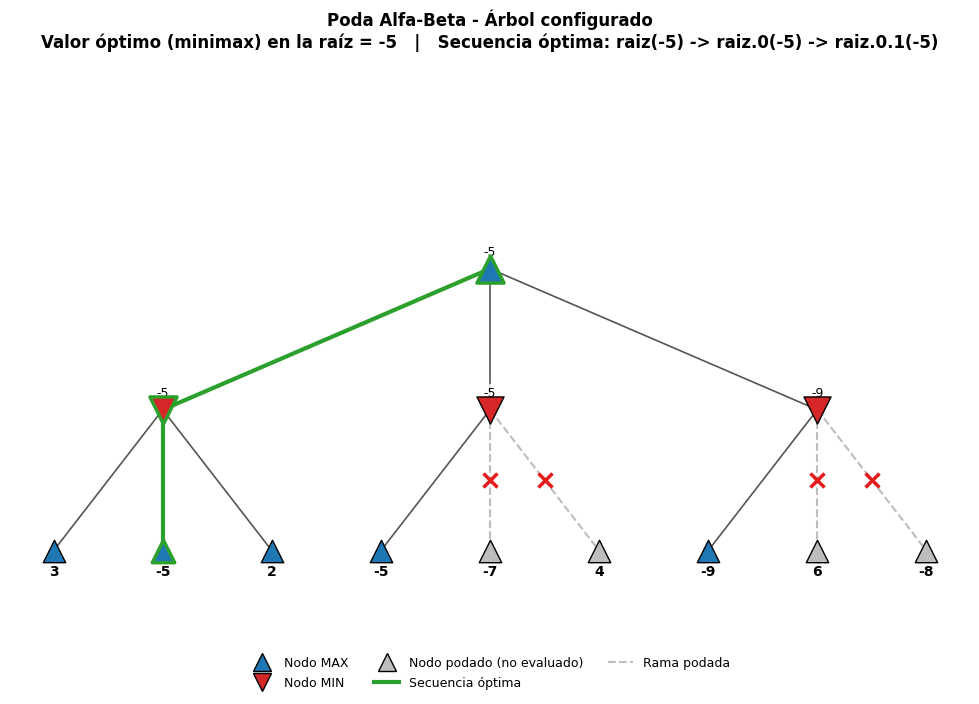

In [9]:
Nodo._contador = 0
raiz = construir_arbol(arbol_entrada)

_contador_visita[0] = 0
valor_optimo = poda_alfabeta(raiz)
secuencia = obtener_secuencia_optima(raiz)

print("Valor óptimo (minimax) en la raíz:", valor_optimo)
print("Secuencia óptima de jugadas:", [n.valor if n.es_hoja else n.valor_calculado for n in secuencia])

fig, ax, seq = dibujar_arbol(raiz, titulo="Poda Alfa-Beta - Árbol configurado")
plt.show()

## 6. Ejecución con un árbol generado aleatoriamente

Se genera un árbol aleatorio indicando el número de **niveles** y el número de
**nodos hoja** deseados, y se ejecuta el mismo proceso de poda y visualización.
Puede modificar `NIVELES`, `NUM_HOJAS` y `SEMILLA` para probar distintos árboles
(hasta 5 niveles y 50 hojas).

Lista generada: [[[[-7], [10]], [[3, -10], [-1]], [[-8], [-1], [-4]]], [[[10], [-7], [-8]], [[-8, -8], [-10]]], [[[1], [5], [9, -1]], [[-6], [9]]]]
Valor óptimo (minimax) en la raíz: 5


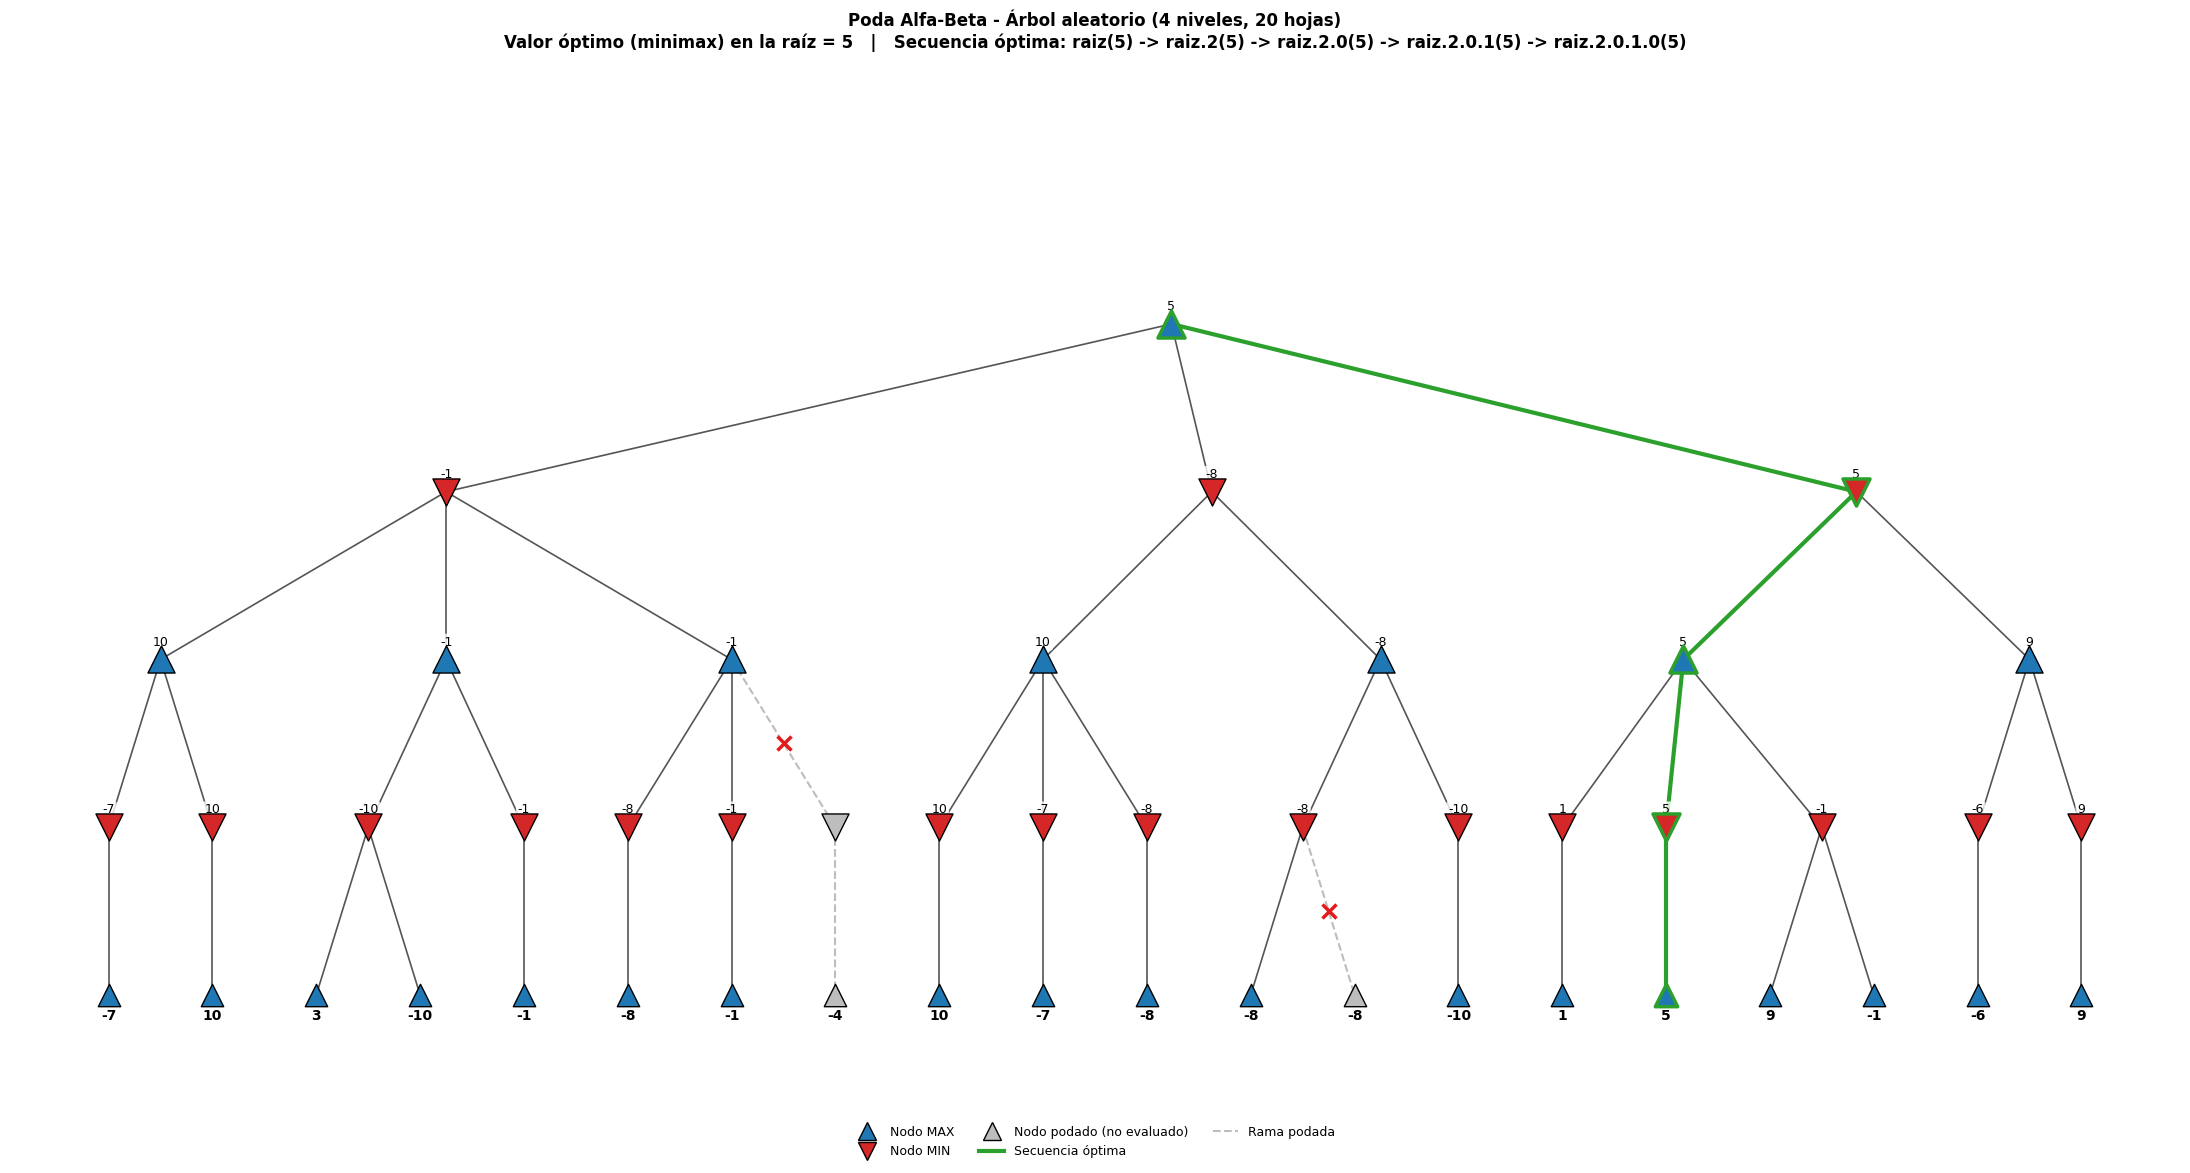

In [10]:
NIVELES = 4
NUM_HOJAS = 20
SEMILLA = None   # use un número (p. ej. 7) si quiere reproducir siempre el mismo árbol

arbol_aleatorio = generar_arbol_aleatorio(niveles=NIVELES, num_hojas=NUM_HOJAS, semilla=SEMILLA)
print("Lista generada:", arbol_aleatorio)

Nodo._contador = 0
raiz_aleatoria = construir_arbol(arbol_aleatorio)

_contador_visita[0] = 0
valor_optimo_aleatorio = poda_alfabeta(raiz_aleatoria)
secuencia_aleatoria = obtener_secuencia_optima(raiz_aleatoria)

print("Valor óptimo (minimax) en la raíz:", valor_optimo_aleatorio)

fig, ax, seq = dibujar_arbol(raiz_aleatoria, titulo=f"Poda Alfa-Beta - Árbol aleatorio ({NIVELES} niveles, {NUM_HOJAS} hojas)")
plt.show()

## 7. Prueba con el tamaño máximo (5 niveles, 50 hojas)

Verificamos que el algoritmo y la visualización funcionan también con el tamaño
máximo permitido por el enunciado.

Valor óptimo (minimax) en la raíz: 4
Número de hojas en el árbol: 50 | Niveles: 5


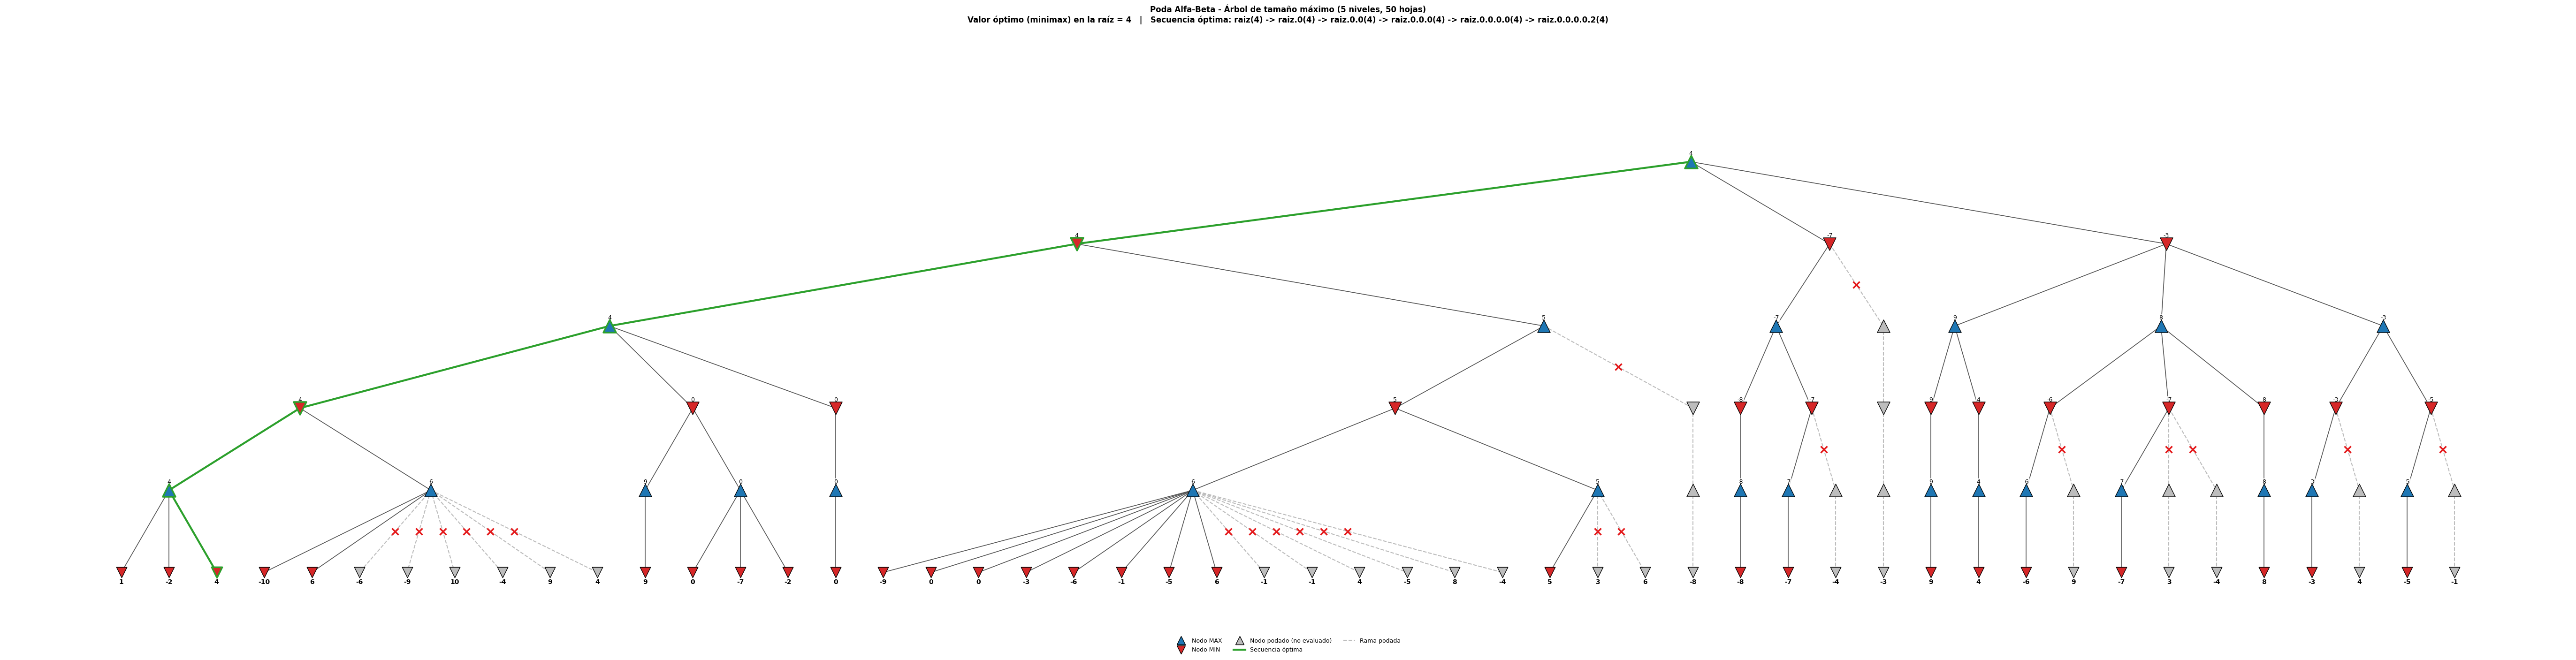

In [12]:
NIVELES_MAX = 5
NUM_HOJAS_MAX = 50

arbol_max = generar_arbol_aleatorio(niveles=NIVELES_MAX, num_hojas=NUM_HOJAS_MAX, semilla=40)

Nodo._contador = 0
raiz_max = construir_arbol(arbol_max)

_contador_visita[0] = 0
valor_max = poda_alfabeta(raiz_max)
print("Valor óptimo (minimax) en la raíz:", valor_max)
print("Número de hojas en el árbol:", NUM_HOJAS_MAX, "| Niveles:", NIVELES_MAX)

fig, ax, seq = dibujar_arbol(raiz_max, titulo="Poda Alfa-Beta - Árbol de tamaño máximo (5 niveles, 50 hojas)")
plt.show()